<a href="https://colab.research.google.com/github/Rashid12Kandah/NMS-vs.-OpenCV-Template-Matching/blob/main/Assignment_3_Rashid_Kandah_20200331.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
from PIL import Image
import imutils

%matplotlib inline

In [24]:
image = cv2.imread("numbers.png")
template = cv2.imread("numbers_template.png")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

In [25]:
result = cv2.matchTemplate(image_gray, template_gray, cv2.TM_CCOEFF_NORMED)


trying thershold 0.99

In [26]:
threshold = 0.99
loc = np.where(result >= threshold)

In [27]:
for pt in zip(*loc[::-1]):
    cv2.rectangle(image, pt, (pt[0] + template.shape[1], pt[1] + template.shape[0]), (0, 0, 0), 2)

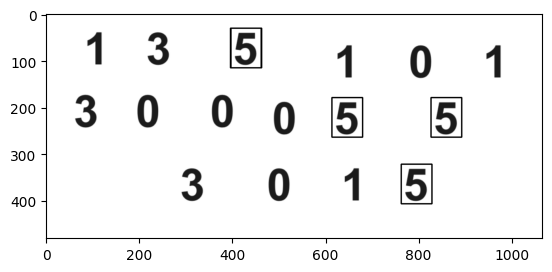

In [28]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

In [29]:
def non_max_suppression(boxes, overlap_thresh):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    pick = []

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    area = (x2 - x1 + 1) * (y2 - y1 + 1)

    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        overlap = (w * h) / area[idxs[:last]]

        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlap_thresh)[0])))

    return boxes[pick]

In [30]:
filtered_boxes = non_max_suppression(loc, overlap_thresh=0.9)

In [33]:
for box in filtered_boxes:
    cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (0, 0, 0), 2)

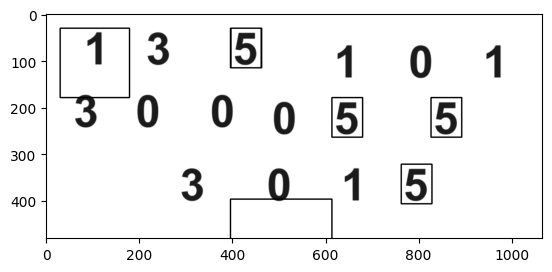

In [32]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()